<a href="https://colab.research.google.com/github/Lehuutien2908/DataMining/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dự đoán nguy cơ mắc bệnh tim

Notebook này trình bày toàn bộ quy trình xử lý dữ liệu, xây dựng và so sánh các mô hình (MLP, Random Forest, XGBoost, SVM) nhằm dự đoán khả năng mắc bệnh tim dựa trên các chỉ số lâm sàng.


## Quy trình tổng quát
- Khảo sát dữ liệu, kiểm tra thiếu và ngoại lệ
- Làm sạch, chuẩn hóa và chọn đặc trưng
- Chia dữ liệu train/test (stratify theo nhãn)
- Huấn luyện MLP (Keras Sequential) và các mô hình so sánh: Random Forest, XGBoost, SVM
- Đánh giá Accuracy, Precision, Recall, F1, Specificity, AUC-ROC


(1025, 14)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

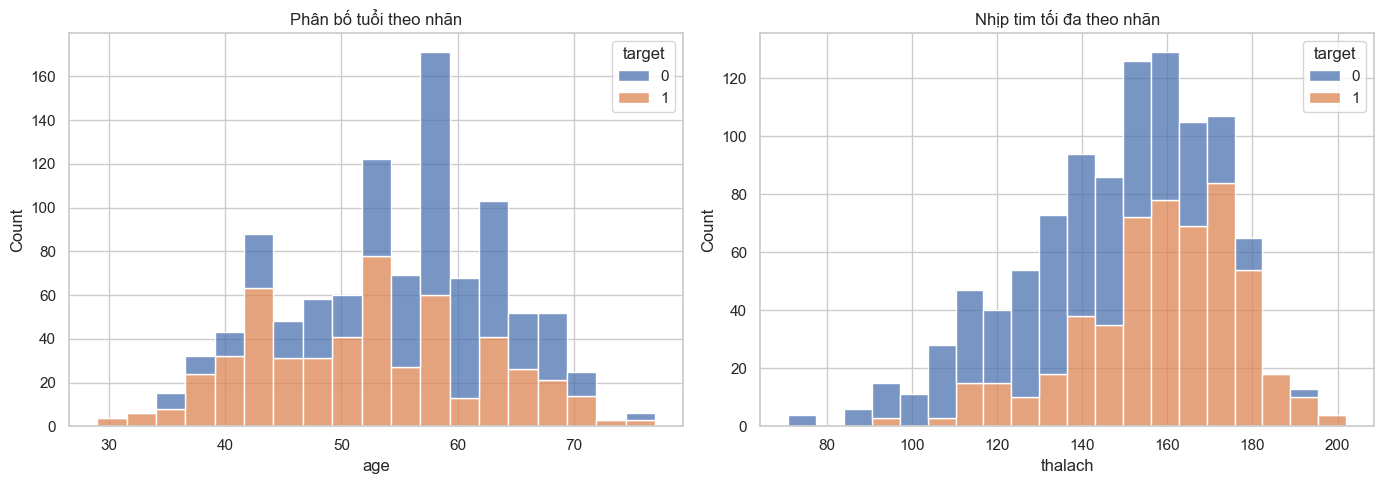

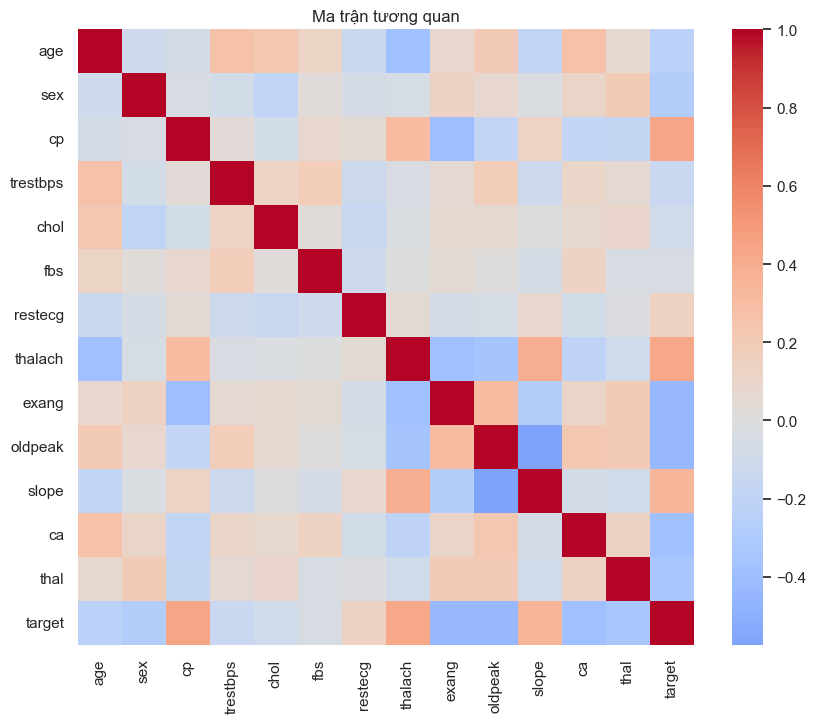

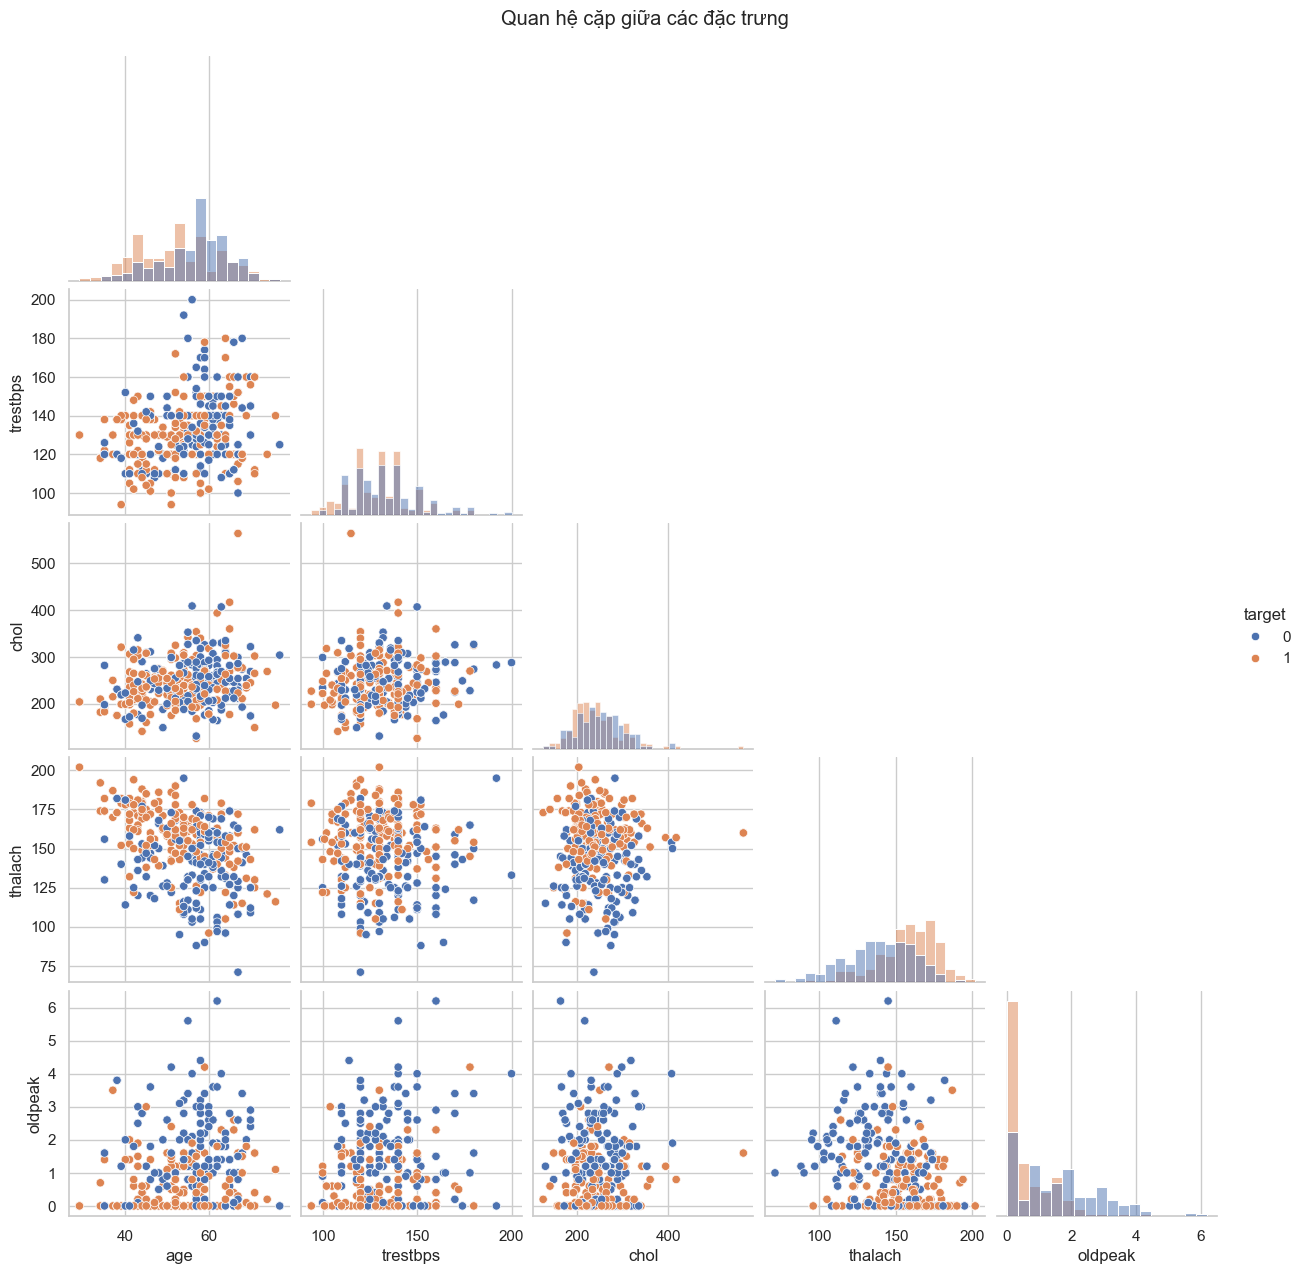

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_PATH = Path("heart.csv")
raw_df = pd.read_csv(DATA_PATH)

display(raw_df.shape)
display(raw_df.describe(include="all"))
display(raw_df.isna().sum())

# Histplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(raw_df, x="age", hue="target", multiple="stack", ax=axes[0])
axes[0].set_title("Phân bố tuổi theo nhãn")

sns.histplot(raw_df, x="thalach", hue="target", multiple="stack", ax=axes[1])
axes[1].set_title("Nhịp tim tối đa theo nhãn")

plt.tight_layout()
plt.show()

# Heatmap tương quan
plt.figure(figsize=(10, 8))
corr = raw_df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Ma trận tương quan")
plt.show()

# Pairplot
pairplot_features = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]
sns.pairplot(raw_df[pairplot_features], hue="target", diag_kind="hist", corner=True)
plt.suptitle("Quan hệ cặp giữa các đặc trưng", y=1.02)
plt.show()
